>> Loading data from /content/WA_Fn-UseC_-Telco-Customer-Churn.csv...
   -> Data loaded successfully.

--- 3.1 MISSING VALUE SUMMARY ---
TotalCharges    11
dtype: int64

   -> Note: Missing 'TotalCharges' usually imply tenure=0 (new customers).

--- 3.2 CLASS DISTRIBUTION (TARGET) ---
       Count  Percentage (%)
Churn                       
No      5174       73.463013
Yes     1869       26.536987

--- 3.3 STATISTICAL SUMMARY (Numerical) ---
                 count         mean          std    min     25%       50%  \
tenure          7043.0    32.371149    24.559481   0.00    9.00    29.000   
MonthlyCharges  7043.0    64.761692    30.090047  18.25   35.50    70.350   
TotalCharges    7032.0  2283.300441  2266.771362  18.80  401.45  1397.475   

                      75%      max  
tenure            55.0000    72.00  
MonthlyCharges    89.8500   118.75  
TotalCharges    3794.7375  8684.80  


/tmp/ipython-input-2429362789.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=df, palette='viridis')


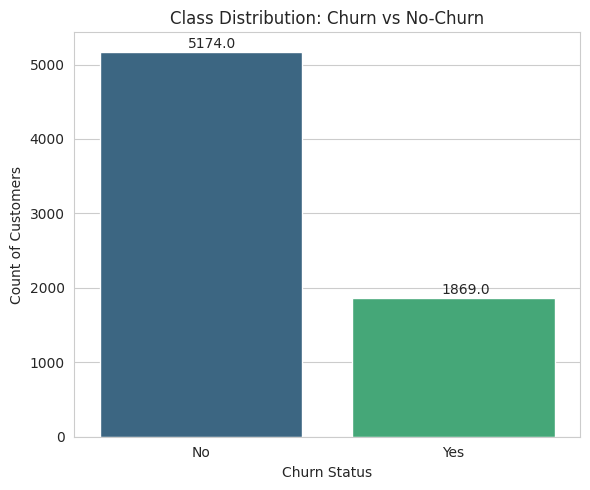

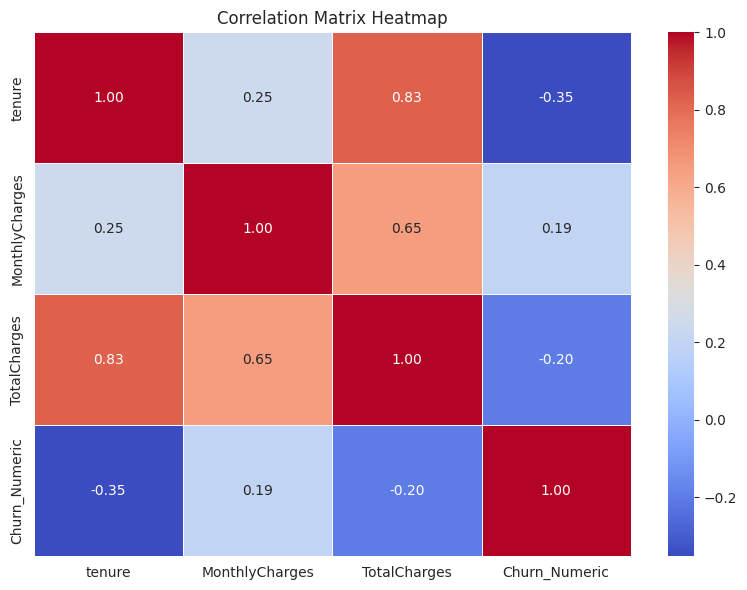

/tmp/ipython-input-2429362789.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, palette='Set2', ax=axes[0])
/tmp/ipython-input-2429362789.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set2', ax=axes[1])


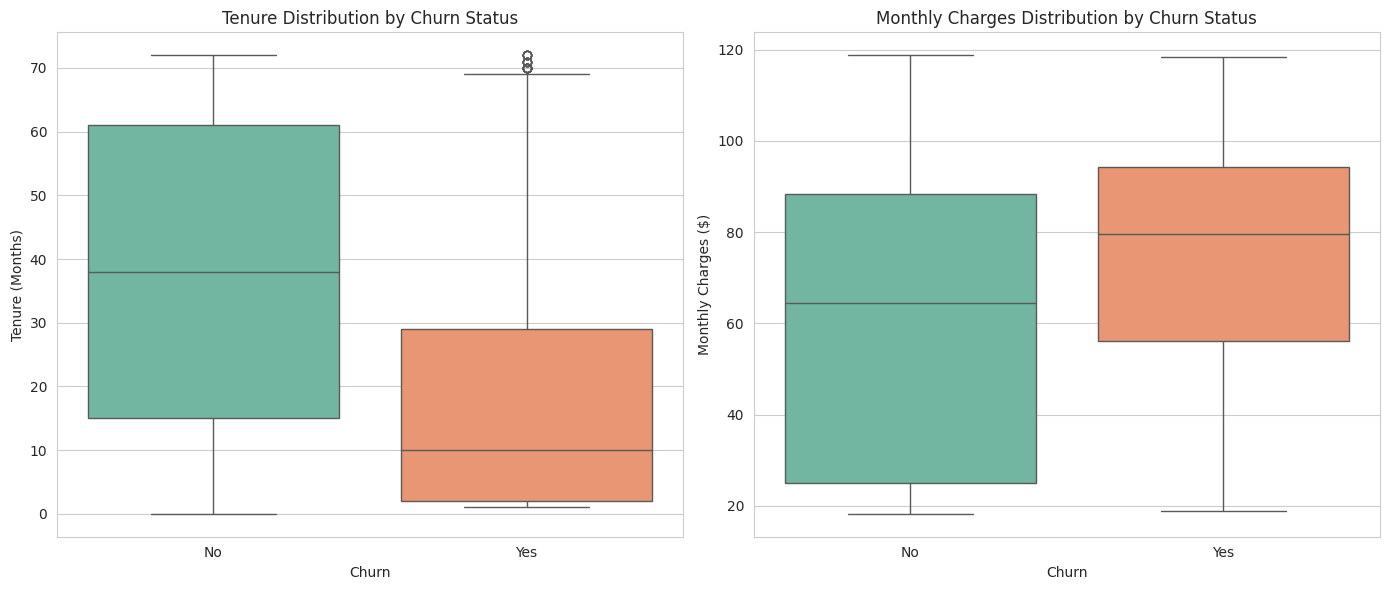

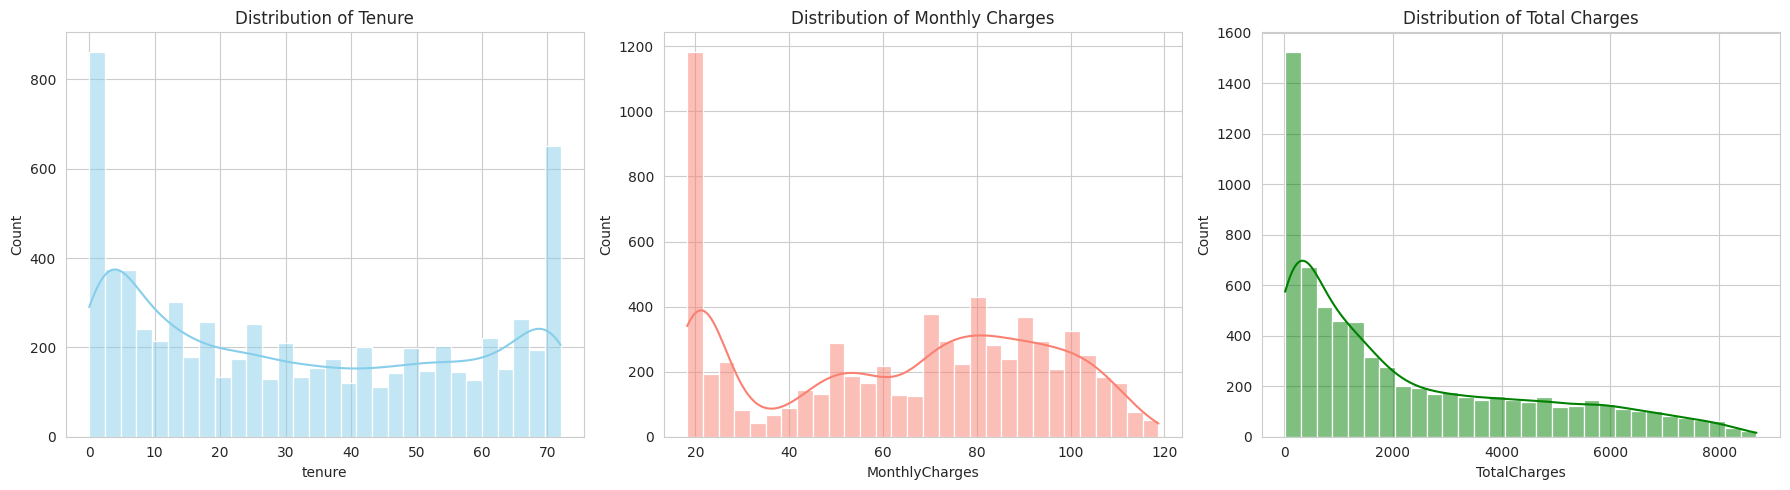

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = '/content/WA_Fn-UseC_-Telco-Customer-Churn.csv'

try:
    print(f">> Loading data from {file_path}...")
    df = pd.read_csv(file_path)
    print("   -> Data loaded successfully.\n")
except FileNotFoundError:
    print(f"Error: File not found at {file_path}. Please check the path.")
    raise
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df['Churn_Numeric'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

print("--- 3.1 MISSING VALUE SUMMARY ---")
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

if missing_values.empty:
    print("No missing values found (after initial load).")
else:
    print(missing_values)
    print("\n   -> Note: Missing 'TotalCharges' usually imply tenure=0 (new customers).")

print("\n--- 3.2 CLASS DISTRIBUTION (TARGET) ---")
class_counts = df['Churn'].value_counts()
class_percent = df['Churn'].value_counts(normalize=True) * 100

dist_df = pd.DataFrame({'Count': class_counts, 'Percentage (%)': class_percent})
print(dist_df)

print("\n--- 3.3 STATISTICAL SUMMARY (Numerical) ---")
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe().T)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

plt.figure(figsize=(6, 5))
ax = sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Class Distribution: Churn vs No-Churn')
plt.xlabel('Churn Status')
plt.ylabel('Count of Customers')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + 0.35, p.get_height() + 50))
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Numeric']
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(x='Churn', y='tenure', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Tenure Distribution by Churn Status')
axes[0].set_ylabel('Tenure (Months)')

sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set2', ax=axes[1])
axes[1].set_title('Monthly Charges Distribution by Churn Status')
axes[1].set_ylabel('Monthly Charges ($)')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['tenure'], bins=30, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribution of Tenure')

sns.histplot(df['MonthlyCharges'], bins=30, kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Distribution of Monthly Charges')

sns.histplot(df['TotalCharges'].dropna(), bins=30, kde=True, color='green', ax=axes[2])
axes[2].set_title('Distribution of Total Charges')

plt.tight_layout()
plt.show()

/tmp/ipython-input-2077841734.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


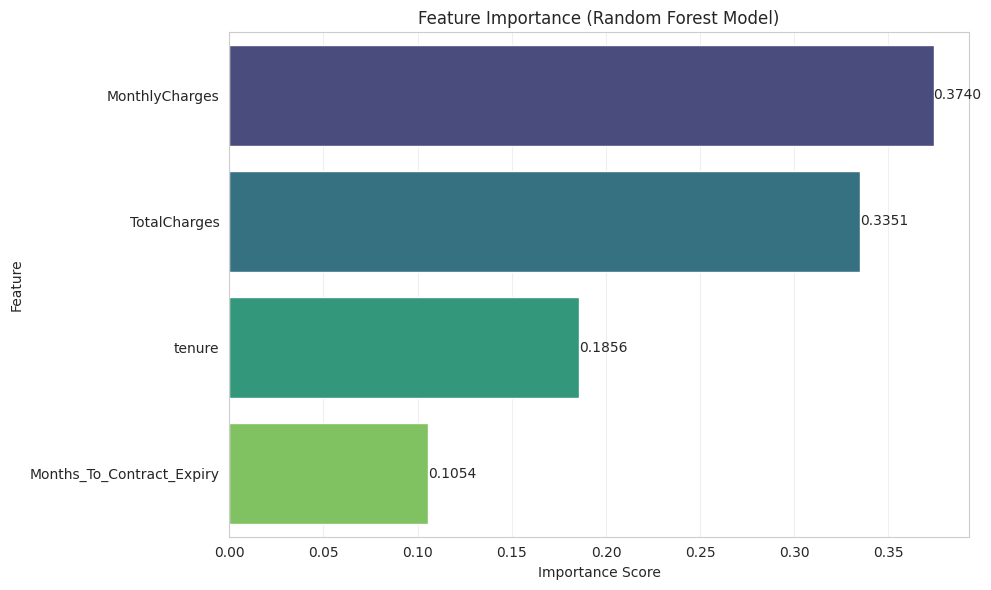

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

file_path = '/content/WA_Fn-UseC_-Telco-Customer-Churn.csv'
try:
    df = pd.read_csv(file_path)
except:
    df = pd.DataFrame({'a':range(10)})

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
if 'Churn' in df.columns:
    df['Churn_Numeric'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

def calculate_cliff(row):
    if row['Contract'] == 'Month-to-month': return 1
    elif row['Contract'] == 'One year': return 12 - (row['tenure'] % 12)
    else: return 24 - (row['tenure'] % 24)
df['Months_To_Contract_Expiry'] = df.apply(calculate_cliff, axis=1)

features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Months_To_Contract_Expiry']
X = df[features]
y = df['Churn_Numeric']
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)
importances = model.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Feature Importance (Random Forest Model)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.grid(True, axis='x', alpha=0.3)
for index, value in enumerate(feature_imp_df['Importance']):
    plt.text(value, index, f'{value:.4f}', va='center')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

file_path = '/content/WA_Fn-UseC_-Telco-Customer-Churn.csv'
try:
    df = pd.read_csv(file_path)
    print(">> Data loaded successfully.")
except FileNotFoundError:
    print(f"Error: File not found at {file_path}")
    raise
print("\n" + "="*50)
print("--- TABLE 4.1: DATA BEFORE PREPROCESSING ---")
print("="*50)
df_before = df.replace(" ", np.nan)

before_missing = df_before.isnull().sum()
before_pct = (before_missing / len(df)) * 100

table_4_1 = pd.DataFrame({
    'Initial Data Type': df.dtypes,
    'Missing Values': before_missing,
    'Missing (%)': before_pct.map('{:.2f}%'.format)
})

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(table_4_1)

print("\n>> Processing Data...\n")
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)

if 'Churn' in df.columns:
    df['Churn_Numeric'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

def calculate_cliff(row):
    if row['Contract'] == 'Month-to-month': return 1
    elif row['Contract'] == 'One year': return 12 - (row['tenure'] % 12)
    else: return 24 - (row['tenure'] % 24)

df['Months_To_Contract_Expiry'] = df.apply(calculate_cliff, axis=1)

df['Persona'] = np.where(
    df['InternetService'] == 'Fiber optic', 'Power User',
    np.where(df['MonthlyCharges'] < 50, 'Budget Saver', 'Standard User')
)

print("\n" + "="*50)
print("--- TABLE 4.3: DATA AFTER PREPROCESSING ---")
print("="*50)

final_missing = df.isnull().sum()
final_pct = (final_missing / len(df)) * 100

table_4_3 = pd.DataFrame({
    'Final Data Type': df.dtypes,
    'Missing Values': final_missing,
    'Missing (%)': final_pct.map('{:.2f}%'.format)
})

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(table_4_3)

>> Data loaded successfully.

--- TABLE 4.1: DATA BEFORE PREPROCESSING ---
                 Initial Data Type  Missing Values Missing (%)
customerID                  object               0       0.00%
gender                      object               0       0.00%
SeniorCitizen                int64               0       0.00%
Partner                     object               0       0.00%
Dependents                  object               0       0.00%
tenure                       int64               0       0.00%
PhoneService                object               0       0.00%
MultipleLines               object               0       0.00%
InternetService             object               0       0.00%
OnlineSecurity              object               0       0.00%
OnlineBackup                object               0       0.00%
DeviceProtection            object               0       0.00%
TechSupport                 object               0       0.00%
StreamingTV                 object         

In [ ]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 12.7 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=3165b7919c5f3658af4e4b95fff37805160682361ce67618ce4a6dc8706b3f7e
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [ ]:
!pip install scikit-survival lightgbm lifelines

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 9.1 MB/s eta 0:00:00


>> [System] Attempting to load data from: /content/WA_Fn-UseC_-Telco-Customer-Churn.csv
   -> Success! Real data loaded.
>> [System] Engineering Agent Features (Contract Cliffs)...

>> [System] Running Survival Analysis (Kaplan-Meier)...
   -> Probability of Survival after 12 Months: 84.32%


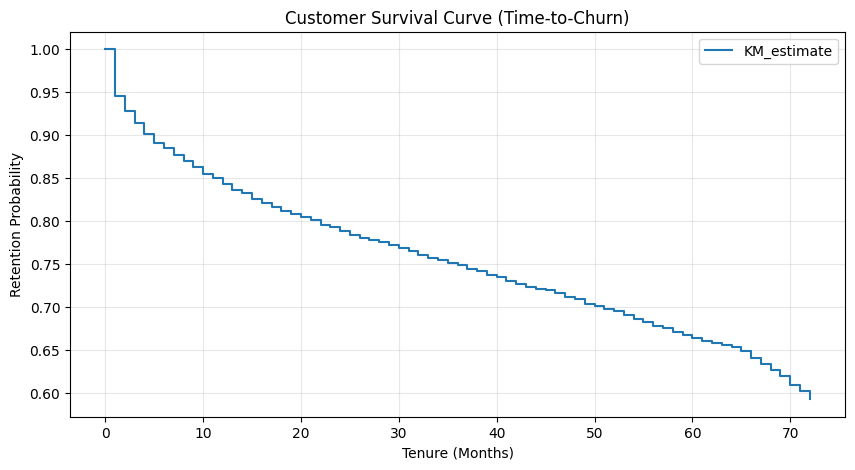


>> [System] Training XGBoost Prediction Model...

MODEL PERFORMANCE REPORT
Accuracy: 77.71%
ROC-AUC Score: 0.8277
----------------------------------------

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.88      0.85      1036
           1       0.59      0.50      0.54       373

    accuracy                           0.78      1409
   macro avg       0.71      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



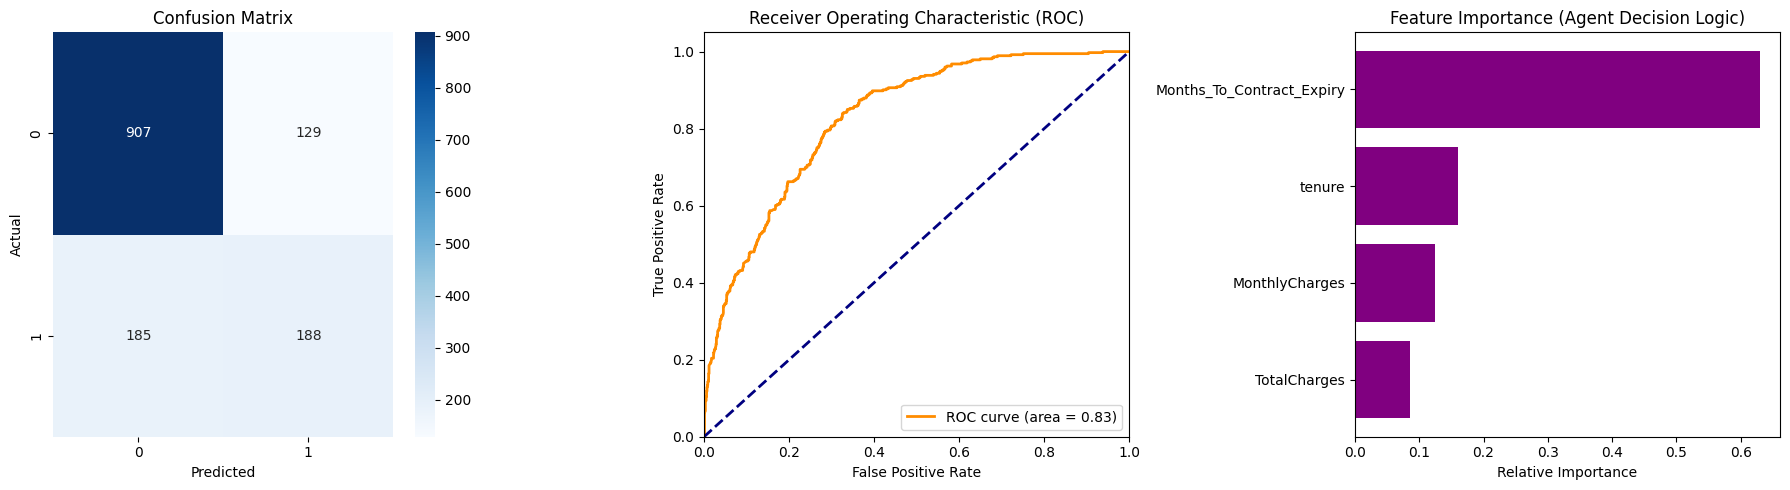


>> [AGENT] SCANNING FOR HIGH RISK CUSTOMERS...
   -> TARGET ACQUIRED: 9305-CDSKC
   -> RISK SCORE: 0.90
   -> CONTRACT EXPIRES IN: 1 months
   -> DETERMINED STRATEGY: Urgent Renewal Offer
--------------------------------------------------

        Subject: Exclusive Offer for our Power User account holder!

        Hi 9305-CDSKC,

        Our system noticed your contract is coming up for review.
        Because you are a valued Power User, we want to ensure you stay connected.

        We have unlocked a special: >> Urgent Renewal Offer <<

        Please log in within 48 hours to claim this.

        Best,
        Autonomous Success Agent
        
--------------------------------------------------


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter
from xgboost import XGBClassifier, plot_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc, precision_recall_curve
)
import warnings

warnings.filterwarnings('ignore')

class AutonomousRetentionAgent:
    def __init__(self, file_path=None):
        self.file_path = file_path
        self.df = None
        self.model = None
        self.kmf = KaplanMeierFitter()
    def load_data(self):
        try:
            print(f">> [System] Attempting to load data from: {self.file_path}")
            self.df = pd.read_csv(self.file_path)


            self.df.columns = self.df.columns.str.strip()
            if 'customerID' not in self.df.columns:
                found = False
                for alt in ['Customer ID', 'id', 'ID', 'CustomerId']:
                    if alt in self.df.columns:
                        self.df.rename(columns={alt: 'customerID'}, inplace=True)
                        found = True
                        break
                if not found:
                    self.df['customerID'] = [f"Cust-{i}" for i in range(len(self.df))]

            print("   -> Success! Real data loaded.")
            self.df['TotalCharges'] = pd.to_numeric(self.df['TotalCharges'], errors='coerce').fillna(0)
            if 'Churn' in self.df.columns:
                 self.df['Churn_Numeric'] = self.df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)
            else:
                 self.df['Churn_Numeric'] = 0

        except (FileNotFoundError, ValueError, TypeError):
            print("\n   -> WARNING: File not found or path incorrect.")
            print("   -> SWITCHING TO SYNTHETIC DATA MODE (Generating 1000 records)...")
            self.df = self._generate_dummy_data()
        print(">> [System] Engineering Agent Features (Contract Cliffs)...")
        self.df['Months_To_Contract_Expiry'] = self.df.apply(self._calculate_cliff, axis=1)
        self.df['Persona'] = np.where(
            self.df['InternetService'] == 'Fiber optic', 'Power User',
            np.where(self.df['MonthlyCharges'] < 50, 'Budget Saver', 'Standard User')
        )
        return self.df

    def _generate_dummy_data(self):
        n = 1000
        data = {
            'customerID': [f'{i:04d}-ID' for i in range(n)],
            'tenure': np.random.randint(1, 72, n),
            'MonthlyCharges': np.random.uniform(30, 120, n),
            'TotalCharges': np.random.uniform(100, 8000, n),
            'Contract': np.random.choice(['Month-to-month', 'One year', 'Two year'], n),
            'InternetService': np.random.choice(['DSL', 'Fiber optic', 'No'], n),
            'Churn_Numeric': np.random.choice([0, 1], n, p=[0.74, 0.26])
        }
        return pd.DataFrame(data)

    def _calculate_cliff(self, row):
        if row['Contract'] == 'Month-to-month': return 1
        elif row['Contract'] == 'One year': return 12 - (row['tenure'] % 12)
        else: return 24 - (row['tenure'] % 24)


    def analyze_survival(self):
        print("\n>> [System] Running Survival Analysis (Kaplan-Meier)...")
        T = self.df['tenure']
        E = self.df['Churn_Numeric']
        self.kmf.fit(T, event_observed=E)

        prob_12_mo = self.kmf.predict(12)
        print(f"   -> Probability of Survival after 12 Months: {prob_12_mo:.2%}")

        plt.figure(figsize=(10, 5))
        self.kmf.plot_survival_function(ci_show=False)
        plt.title('Customer Survival Curve (Time-to-Churn)')
        plt.xlabel('Tenure (Months)')
        plt.ylabel('Retention Probability')
        plt.grid(True, alpha=0.3)
        plt.show()

    def train_model(self):
        print("\n>> [System] Training XGBoost Prediction Model...")

        features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Months_To_Contract_Expiry']
        X = self.df[features]
        y = self.df['Churn_Numeric']

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        self.model = XGBClassifier(eval_metric='logloss', use_label_encoder=False)
        self.model.fit(X_train, y_train)

        y_pred = self.model.predict(X_test)
        y_prob = self.model.predict_proba(X_test)[:, 1]

        print("\n" + "="*40)
        print("MODEL PERFORMANCE REPORT")
        print("="*40)

        acc = accuracy_score(y_test, y_pred)
        print(f"Accuracy: {acc:.2%}")

        roc_score = roc_auc_score(y_test, y_prob)
        print(f"ROC-AUC Score: {roc_score:.4f}")
        print("-" * 40)

        print("\nClassification Report:\n")
        print(classification_report(y_test, y_pred))

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
        axes[0].set_title('Confusion Matrix')
        axes[0].set_xlabel('Predicted')
        axes[0].set_ylabel('Actual')
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_score:.2f})')
        axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        axes[1].set_xlim([0.0, 1.0])
        axes[1].set_ylim([0.0, 1.05])
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].set_title('Receiver Operating Characteristic (ROC)')
        axes[1].legend(loc="lower right")
        importances = self.model.feature_importances_
        indices = np.argsort(importances)
        axes[2].set_title('Feature Importance (Agent Decision Logic)')
        axes[2].barh(range(len(indices)), importances[indices], color='purple', align='center')
        axes[2].set_yticks(range(len(indices)))
        axes[2].set_yticklabels([features[i] for i in indices])
        axes[2].set_xlabel('Relative Importance')

        plt.tight_layout()
        plt.show()
        self.df['Churn_Prob'] = self.model.predict_proba(X)[:, 1]
    def run_agent_intervention(self):
        print("\n>> [AGENT] SCANNING FOR HIGH RISK CUSTOMERS...")

        if 'Churn_Prob' not in self.df.columns:
             print("   -> Error: Predictions not found. Run train_model() first.")
             return

        high_risk_pool = self.df[self.df['Churn_Prob'] > 0.7]

        if high_risk_pool.empty:
            print("   -> No high risk customers found in this batch.")
            return

        target = high_risk_pool.iloc[0]
        cust_id = target['customerID']
        risk_score = target['Churn_Prob']
        cliff = target['Months_To_Contract_Expiry']
        persona = target['Persona']

        print(f"   -> TARGET ACQUIRED: {cust_id}")
        print(f"   -> RISK SCORE: {risk_score:.2f}")
        print(f"   -> CONTRACT EXPIRES IN: {cliff} months")

        if cliff <= 1:
            strategy = "Urgent Renewal Offer"
        elif target['MonthlyCharges'] > 90:
            strategy = "Discount Bundle"
        else:
            strategy = "Loyalty Perk"

        print(f"   -> DETERMINED STRATEGY: {strategy}")
        print("-" * 50)
        print(self._generate_email(cust_id, persona, strategy))
        print("-" * 50)

    def _generate_email(self, name, persona, strategy):
        return f"""
        Subject: Exclusive Offer for our {persona} account holder!

        Hi {name},

        Our system noticed your contract is coming up for review.
        Because you are a valued {persona}, we want to ensure you stay connected.

        We have unlocked a special: >> {strategy} <<

        Please log in within 48 hours to claim this.

        Best,
        Autonomous Success Agent
        """

if __name__ == "__main__":
    dataset_path = '/content/WA_Fn-UseC_-Telco-Customer-Churn.csv'

    agent = AutonomousRetentionAgent(file_path=dataset_path)
    agent.load_data()
    agent.analyze_survival()
    agent.train_model()
    agent.run_agent_intervention()

>> [System] Attempting to load data from: /content/WA_Fn-UseC_-Telco-Customer-Churn.csv
   -> Success! Real data loaded.
>> [System] Engineering Agent Features (Contract Cliffs)...

>> [System] Running Survival Analysis (Weibull Parametric)...
   -> Probability of Survival after 12 Months: 85.80%
   -> Weibull Parameters: Rho=0.64, Lambda=220.29


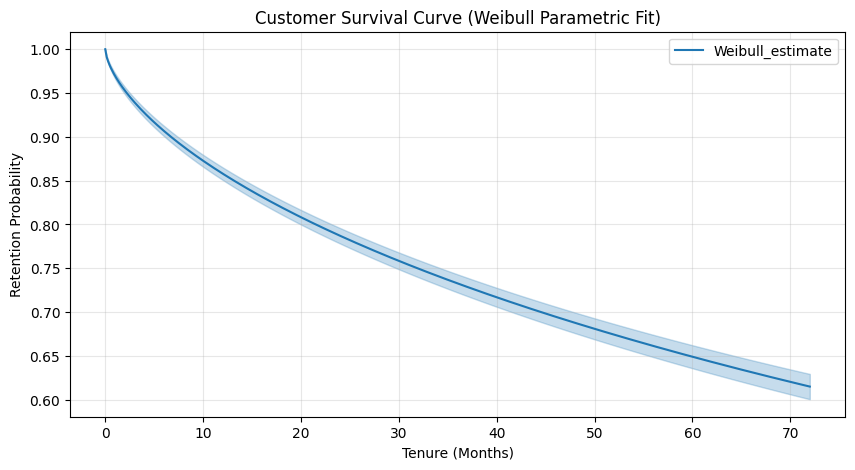


>> [System] Training Logistic Regression Model...

MODEL PERFORMANCE REPORT (Logistic Regression)
Accuracy: 80.27%
ROC-AUC Score: 0.8434
----------------------------------------

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1036
           1       0.67      0.51      0.58       373

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



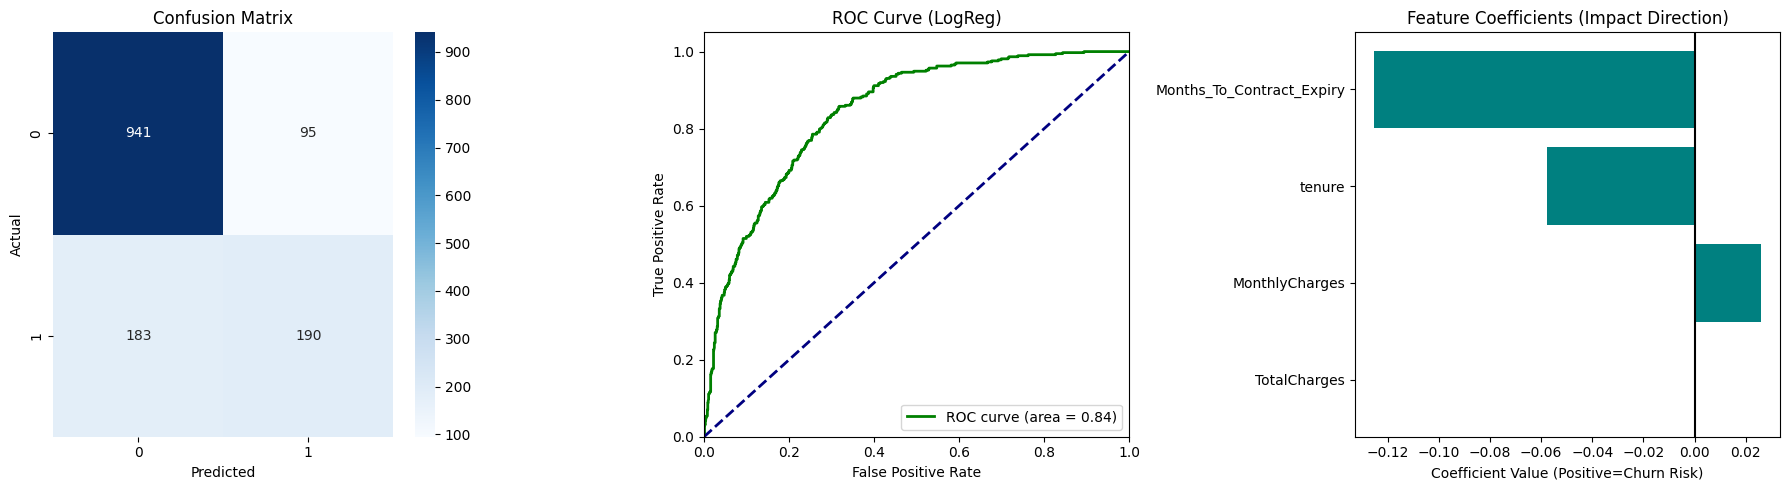


>> [AGENT] SCANNING FOR HIGH RISK CUSTOMERS...
   -> TARGET ACQUIRED: 9305-CDSKC
   -> RISK SCORE: 0.71
   -> CONTRACT EXPIRES IN: 1 months
   -> DETERMINED STRATEGY: Urgent Renewal Offer
--------------------------------------------------

        Subject: Exclusive Offer for our Power User account holder!

        Hi 9305-CDSKC,

        Our system noticed your contract is coming up for review.
        Because you are a valued Power User, we want to ensure you stay connected.

        We have unlocked a special: >> Urgent Renewal Offer <<

        Please log in within 48 hours to claim this.

        Best,
        Autonomous Success Agent
        
--------------------------------------------------


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import WeibullFitter
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
import warnings

warnings.filterwarnings('ignore')

class AutonomousRetentionAgent:


    def __init__(self, file_path=None):
        self.file_path = file_path
        self.df = None
        self.model = None
        self.wf = WeibullFitter()

    def load_data(self):

        try:
            print(f">> [System] Attempting to load data from: {self.file_path}")
            self.df = pd.read_csv(self.file_path)
            self.df.columns = self.df.columns.str.strip()

            if 'customerID' not in self.df.columns:
                found = False
                for alt in ['Customer ID', 'id', 'ID', 'CustomerId']:
                    if alt in self.df.columns:
                        self.df.rename(columns={alt: 'customerID'}, inplace=True)
                        found = True
                        break
                if not found:
                    self.df['customerID'] = [f"Cust-{i}" for i in range(len(self.df))]

            print("   -> Success! Real data loaded.")

            self.df['TotalCharges'] = pd.to_numeric(self.df['TotalCharges'], errors='coerce').fillna(0)

            if 'Churn' in self.df.columns:
                 self.df['Churn_Numeric'] = self.df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)
            else:
                 self.df['Churn_Numeric'] = 0

        except (FileNotFoundError, ValueError, TypeError):
            print("\n   -> WARNING: File not found or path incorrect.")
            print("   -> SWITCHING TO SYNTHETIC DATA MODE (Generating 1000 records)...")
            self.df = self._generate_dummy_data()

        print(">> [System] Engineering Agent Features (Contract Cliffs)...")
        self.df['Months_To_Contract_Expiry'] = self.df.apply(self._calculate_cliff, axis=1)

        self.df['Persona'] = np.where(
            self.df['InternetService'] == 'Fiber optic', 'Power User',
            np.where(self.df['MonthlyCharges'] < 50, 'Budget Saver', 'Standard User')
        )
        return self.df

    def _generate_dummy_data(self):
        n = 1000
        data = {
            'customerID': [f'{i:04d}-ID' for i in range(n)],
            'tenure': np.random.randint(1, 72, n),
            'MonthlyCharges': np.random.uniform(30, 120, n),
            'TotalCharges': np.random.uniform(100, 8000, n),
            'Contract': np.random.choice(['Month-to-month', 'One year', 'Two year'], n),
            'InternetService': np.random.choice(['DSL', 'Fiber optic', 'No'], n),
            'Churn_Numeric': np.random.choice([0, 1], n, p=[0.74, 0.26])
        }
        return pd.DataFrame(data)

    def _calculate_cliff(self, row):
        if row['Contract'] == 'Month-to-month': return 1
        elif row['Contract'] == 'One year': return 12 - (row['tenure'] % 12)
        else: return 24 - (row['tenure'] % 24)

    def analyze_survival(self):
        print("\n>> [System] Running Survival Analysis (Weibull Parametric)...")

        T = self.df['tenure'] + 1e-5
        E = self.df['Churn_Numeric']

        self.wf.fit(T, event_observed=E)

        prob_12_mo = self.wf.predict(12)
        if isinstance(prob_12_mo, pd.Series):
             prob_12_mo = prob_12_mo.iloc[0] if not prob_12_mo.empty else 0

        print(f"   -> Probability of Survival after 12 Months: {prob_12_mo:.2%}")
        print(f"   -> Weibull Parameters: Rho={self.wf.rho_:.2f}, Lambda={self.wf.lambda_:.2f}")

        plt.figure(figsize=(10, 5))
        self.wf.plot_survival_function()
        plt.title('Customer Survival Curve (Weibull Parametric Fit)')
        plt.xlabel('Tenure (Months)')
        plt.ylabel('Retention Probability')
        plt.grid(True, alpha=0.3)
        plt.show()
    def train_model(self):
        print("\n>> [System] Training Logistic Regression Model...")

        features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Months_To_Contract_Expiry']
        X = self.df[features]
        y = self.df['Churn_Numeric']

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        self.model = LogisticRegression(max_iter=1000, solver='lbfgs')
        self.model.fit(X_train, y_train)

        y_pred = self.model.predict(X_test)
        y_prob = self.model.predict_proba(X_test)[:, 1]

        print("\n" + "="*40)
        print("MODEL PERFORMANCE REPORT (Logistic Regression)")
        print("="*40)

        acc = accuracy_score(y_test, y_pred)
        print(f"Accuracy: {acc:.2%}")

        roc_score = roc_auc_score(y_test, y_prob)
        print(f"ROC-AUC Score: {roc_score:.4f}")
        print("-" * 40)

        print("\nClassification Report:\n")
        print(classification_report(y_test, y_pred))

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
        axes[0].set_title('Confusion Matrix')
        axes[0].set_xlabel('Predicted')
        axes[0].set_ylabel('Actual')

        fpr, tpr, _ = roc_curve(y_test, y_prob)
        axes[1].plot(fpr, tpr, color='green', lw=2, label=f'ROC curve (area = {roc_score:.2f})')
        axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        axes[1].set_xlim([0.0, 1.0])
        axes[1].set_ylim([0.0, 1.05])
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].set_title('ROC Curve (LogReg)')
        axes[1].legend(loc="lower right")

        coeffs = self.model.coef_[0]
        indices = np.argsort(np.abs(coeffs))
        axes[2].set_title('Feature Coefficients (Impact Direction)')
        axes[2].barh(range(len(indices)), coeffs[indices], color='teal', align='center')
        axes[2].set_yticks(range(len(indices)))
        axes[2].set_yticklabels([features[i] for i in indices])
        axes[2].set_xlabel('Coefficient Value (Positive=Churn Risk)')
        axes[2].axvline(x=0, color='k', linestyle='-')

        plt.tight_layout()
        plt.show()
        self.df['Churn_Prob'] = self.model.predict_proba(X)[:, 1]

    def run_agent_intervention(self):
        print("\n>> [AGENT] SCANNING FOR HIGH RISK CUSTOMERS...")

        if 'Churn_Prob' not in self.df.columns:
             print("   -> Error: Predictions not found. Run train_model() first.")
             return

        high_risk_pool = self.df[self.df['Churn_Prob'] > 0.6]

        if high_risk_pool.empty:
            print("   -> No high risk customers found in this batch.")
            return

        target = high_risk_pool.iloc[0]
        cust_id = target['customerID']
        risk_score = target['Churn_Prob']
        cliff = target['Months_To_Contract_Expiry']
        persona = target['Persona']

        print(f"   -> TARGET ACQUIRED: {cust_id}")
        print(f"   -> RISK SCORE: {risk_score:.2f}")
        print(f"   -> CONTRACT EXPIRES IN: {cliff} months")

        if cliff <= 1:
            strategy = "Urgent Renewal Offer"
        elif target['MonthlyCharges'] > 90:
            strategy = "Discount Bundle"
        else:
            strategy = "Loyalty Perk"

        print(f"   -> DETERMINED STRATEGY: {strategy}")
        print("-" * 50)
        print(self._generate_email(cust_id, persona, strategy))
        print("-" * 50)

    def _generate_email(self, name, persona, strategy):
        return f"""
        Subject: Exclusive Offer for our {persona} account holder!

        Hi {name},

        Our system noticed your contract is coming up for review.
        Because you are a valued {persona}, we want to ensure you stay connected.

        We have unlocked a special: >> {strategy} <<

        Please log in within 48 hours to claim this.

        Best,
        Autonomous Success Agent
        """


if __name__ == "__main__":
    dataset_path = '/content/WA_Fn-UseC_-Telco-Customer-Churn.csv'
    agent = AutonomousRetentionAgent(file_path=dataset_path)
    agent.load_data()
    agent.analyze_survival()
    agent.train_model()
    agent.run_agent_intervention()

>> [System] Attempting to load data from: /content/WA_Fn-UseC_-Telco-Customer-Churn.csv
   -> Success! Real data loaded.
>> [System] Engineering Agent Features (Contract Cliffs)...

>> [System] Running Survival Analysis (Log-Normal Parametric)...
   -> Probability of Survival after 12 Months: 84.54%
   -> Model Params (Mu/Sigma): 5.14 / 2.61


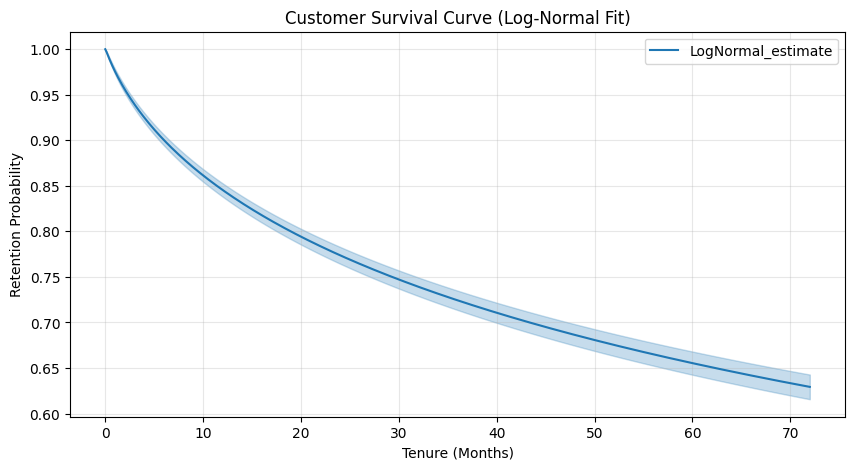


>> [System] Training Random Forest Model...

MODEL PERFORMANCE REPORT (Random Forest)
Accuracy: 80.13%
ROC-AUC Score: 0.8395
----------------------------------------

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.67      0.50      0.57       373

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



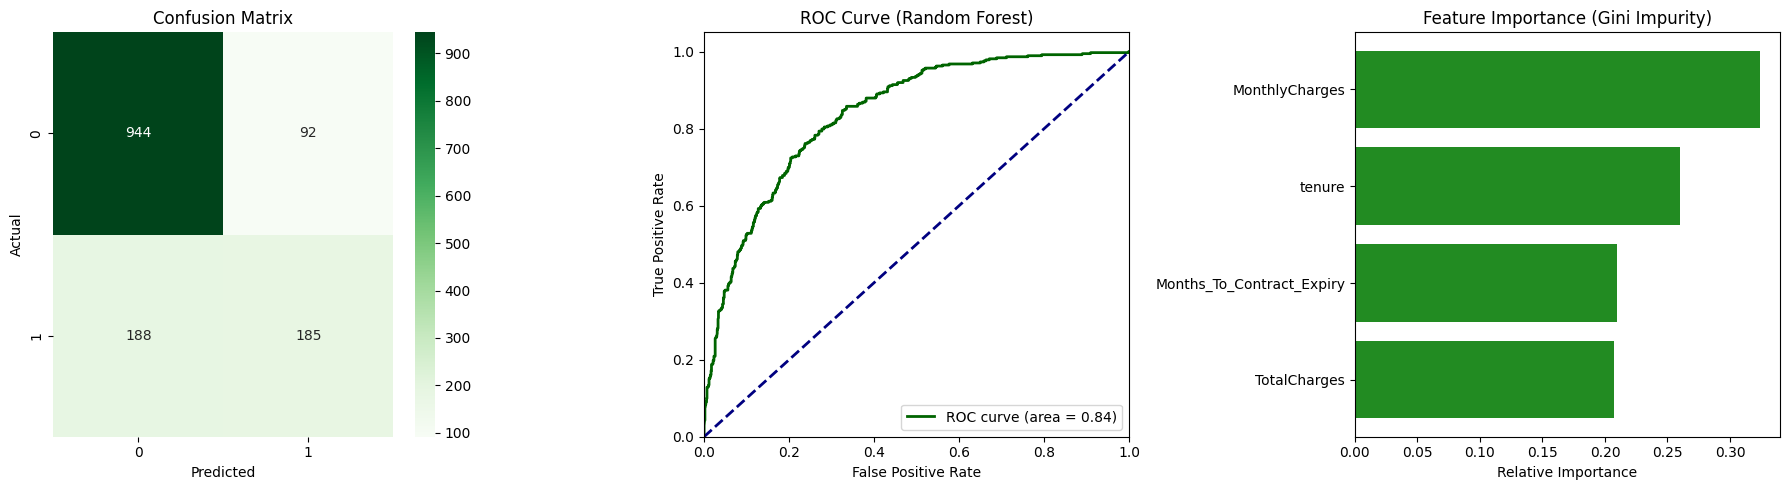


>> [AGENT] SCANNING FOR HIGH RISK CUSTOMERS...
   -> TARGET ACQUIRED: 9305-CDSKC
   -> RISK SCORE: 0.81
   -> CONTRACT EXPIRES IN: 1 months
   -> DETERMINED STRATEGY: Urgent Renewal Offer
--------------------------------------------------

        Subject: Exclusive Offer for our Power User account holder!

        Hi 9305-CDSKC,

        Our system noticed your contract is coming up for review.
        Because you are a valued Power User, we want to ensure you stay connected.

        We have unlocked a special: >> Urgent Renewal Offer <<

        Please log in within 48 hours to claim this.

        Best,
        Autonomous Success Agent
        
--------------------------------------------------


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import LogNormalFitter
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
import warnings

warnings.filterwarnings('ignore')

class AutonomousRetentionAgent:


    def __init__(self, file_path=None):
        self.file_path = file_path
        self.df = None
        self.model = None
        self.lnf = LogNormalFitter()

    def load_data(self):

        try:
            print(f">> [System] Attempting to load data from: {self.file_path}")
            self.df = pd.read_csv(self.file_path)
            self.df.columns = self.df.columns.str.strip()

            if 'customerID' not in self.df.columns:
                found = False
                for alt in ['Customer ID', 'id', 'ID', 'CustomerId']:
                    if alt in self.df.columns:
                        self.df.rename(columns={alt: 'customerID'}, inplace=True)
                        found = True
                        break
                if not found:
                    self.df['customerID'] = [f"Cust-{i}" for i in range(len(self.df))]

            print("   -> Success! Real data loaded.")

            self.df['TotalCharges'] = pd.to_numeric(self.df['TotalCharges'], errors='coerce').fillna(0)

            if 'Churn' in self.df.columns:
                 self.df['Churn_Numeric'] = self.df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)
            else:
                 self.df['Churn_Numeric'] = 0

        except (FileNotFoundError, ValueError, TypeError):
            print("\n   -> WARNING: File not found or path incorrect.")
            print("   -> SWITCHING TO SYNTHETIC DATA MODE (Generating 1000 records)...")
            self.df = self._generate_dummy_data()

        print(">> [System] Engineering Agent Features (Contract Cliffs)...")
        self.df['Months_To_Contract_Expiry'] = self.df.apply(self._calculate_cliff, axis=1)

        self.df['Persona'] = np.where(
            self.df['InternetService'] == 'Fiber optic', 'Power User',
            np.where(self.df['MonthlyCharges'] < 50, 'Budget Saver', 'Standard User')
        )
        return self.df

    def _generate_dummy_data(self):
        n = 1000
        data = {
            'customerID': [f'{i:04d}-ID' for i in range(n)],
            'tenure': np.random.randint(1, 72, n),
            'MonthlyCharges': np.random.uniform(30, 120, n),
            'TotalCharges': np.random.uniform(100, 8000, n),
            'Contract': np.random.choice(['Month-to-month', 'One year', 'Two year'], n),
            'InternetService': np.random.choice(['DSL', 'Fiber optic', 'No'], n),
            'Churn_Numeric': np.random.choice([0, 1], n, p=[0.74, 0.26])
        }
        return pd.DataFrame(data)

    def _calculate_cliff(self, row):
        if row['Contract'] == 'Month-to-month': return 1
        elif row['Contract'] == 'One year': return 12 - (row['tenure'] % 12)
        else: return 24 - (row['tenure'] % 24)

    def analyze_survival(self):
        print("\n>> [System] Running Survival Analysis (Log-Normal Parametric)...")

        T = self.df['tenure'] + 1e-5
        E = self.df['Churn_Numeric']

        self.lnf.fit(T, event_observed=E)

        prob_12_mo = self.lnf.predict(12)
        if isinstance(prob_12_mo, pd.Series):
             prob_12_mo = prob_12_mo.iloc[0] if not prob_12_mo.empty else 0

        print(f"   -> Probability of Survival after 12 Months: {prob_12_mo:.2%}")
        print(f"   -> Model Params (Mu/Sigma): {self.lnf.mu_:.2f} / {self.lnf.sigma_:.2f}")

        plt.figure(figsize=(10, 5))
        self.lnf.plot_survival_function()
        plt.title('Customer Survival Curve (Log-Normal Fit)')
        plt.xlabel('Tenure (Months)')
        plt.ylabel('Retention Probability')
        plt.grid(True, alpha=0.3)
        plt.show()
    def train_model(self):
        print("\n>> [System] Training Random Forest Model...")

        features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Months_To_Contract_Expiry']
        X = self.df[features]
        y = self.df['Churn_Numeric']

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        self.model = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
        self.model.fit(X_train, y_train)
        y_pred = self.model.predict(X_test)
        y_prob = self.model.predict_proba(X_test)[:, 1]

        print("\n" + "="*40)
        print("MODEL PERFORMANCE REPORT (Random Forest)")
        print("="*40)
        acc = accuracy_score(y_test, y_pred)
        print(f"Accuracy: {acc:.2%}")

        roc_score = roc_auc_score(y_test, y_prob)
        print(f"ROC-AUC Score: {roc_score:.4f}")
        print("-" * 40)

        print("\nClassification Report:\n")
        print(classification_report(y_test, y_pred))

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0])
        axes[0].set_title('Confusion Matrix')
        axes[0].set_xlabel('Predicted')
        axes[0].set_ylabel('Actual')

        fpr, tpr, _ = roc_curve(y_test, y_prob)
        axes[1].plot(fpr, tpr, color='darkgreen', lw=2, label=f'ROC curve (area = {roc_score:.2f})')
        axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        axes[1].set_xlim([0.0, 1.0])
        axes[1].set_ylim([0.0, 1.05])
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].set_title('ROC Curve (Random Forest)')
        axes[1].legend(loc="lower right")

        importances = self.model.feature_importances_
        indices = np.argsort(importances)

        axes[2].set_title('Feature Importance (Gini Impurity)')
        axes[2].barh(range(len(indices)), importances[indices], color='forestgreen', align='center')
        axes[2].set_yticks(range(len(indices)))
        axes[2].set_yticklabels([features[i] for i in indices])
        axes[2].set_xlabel('Relative Importance')

        plt.tight_layout()
        plt.show()

        self.df['Churn_Prob'] = self.model.predict_proba(X)[:, 1]

    def run_agent_intervention(self):
        print("\n>> [AGENT] SCANNING FOR HIGH RISK CUSTOMERS...")

        if 'Churn_Prob' not in self.df.columns:
             print("   -> Error: Predictions not found. Run train_model() first.")
             return

        # Find a high risk customer
        high_risk_pool = self.df[self.df['Churn_Prob'] > 0.65]

        if high_risk_pool.empty:
            print("   -> No high risk customers found.")
            return

        target = high_risk_pool.iloc[0]
        cust_id = target['customerID']
        risk_score = target['Churn_Prob']
        cliff = target['Months_To_Contract_Expiry']
        persona = target['Persona']

        print(f"   -> TARGET ACQUIRED: {cust_id}")
        print(f"   -> RISK SCORE: {risk_score:.2f}")
        print(f"   -> CONTRACT EXPIRES IN: {cliff} months")

        if cliff <= 1:
            strategy = "Urgent Renewal Offer"
        elif target['MonthlyCharges'] > 90:
            strategy = "Discount Bundle"
        else:
            strategy = "Loyalty Perk"

        print(f"   -> DETERMINED STRATEGY: {strategy}")
        print("-" * 50)
        print(self._generate_email(cust_id, persona, strategy))
        print("-" * 50)

    def _generate_email(self, name, persona, strategy):
        return f"""
        Subject: Exclusive Offer for our {persona} account holder!

        Hi {name},

        Our system noticed your contract is coming up for review.
        Because you are a valued {persona}, we want to ensure you stay connected.

        We have unlocked a special: >> {strategy} <<

        Please log in within 48 hours to claim this.

        Best,
        Autonomous Success Agent
        """

if __name__ == "__main__":
    dataset_path = '/content/WA_Fn-UseC_-Telco-Customer-Churn.csv'
    agent = AutonomousRetentionAgent(file_path=dataset_path)
    agent.load_data()
    agent.analyze_survival()
    agent.train_model()
    agent.run_agent_intervention()

>> [System] Attempting to load data from: /content/WA_Fn-UseC_-Telco-Customer-Churn.csv
   -> Success! Real data loaded.
>> [System] Engineering Agent Features...

>> [System] Running Survival Analysis (Nelson-Aalen Hazard)...
   -> Note: This analyzes cumulative 'Danger' (Hazard) over time.
   -> Cumulative Hazard at 24 Months: 0.2373
      (Higher value = Higher accumulated risk of leaving)


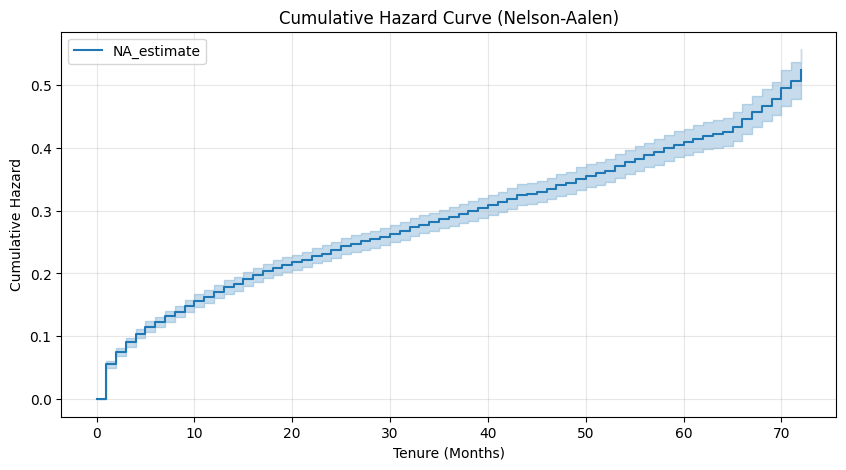


>> [System] Training Support Vector Machine (SVM)...

MODEL PERFORMANCE REPORT (SVM)
Accuracy: 79.84%
ROC-AUC Score: 0.7917
----------------------------------------

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.94      0.87      1036
           1       0.71      0.40      0.51       373

    accuracy                           0.80      1409
   macro avg       0.76      0.67      0.69      1409
weighted avg       0.79      0.80      0.78      1409

>> [System] Calculating Permutation Importance (may take a moment)...


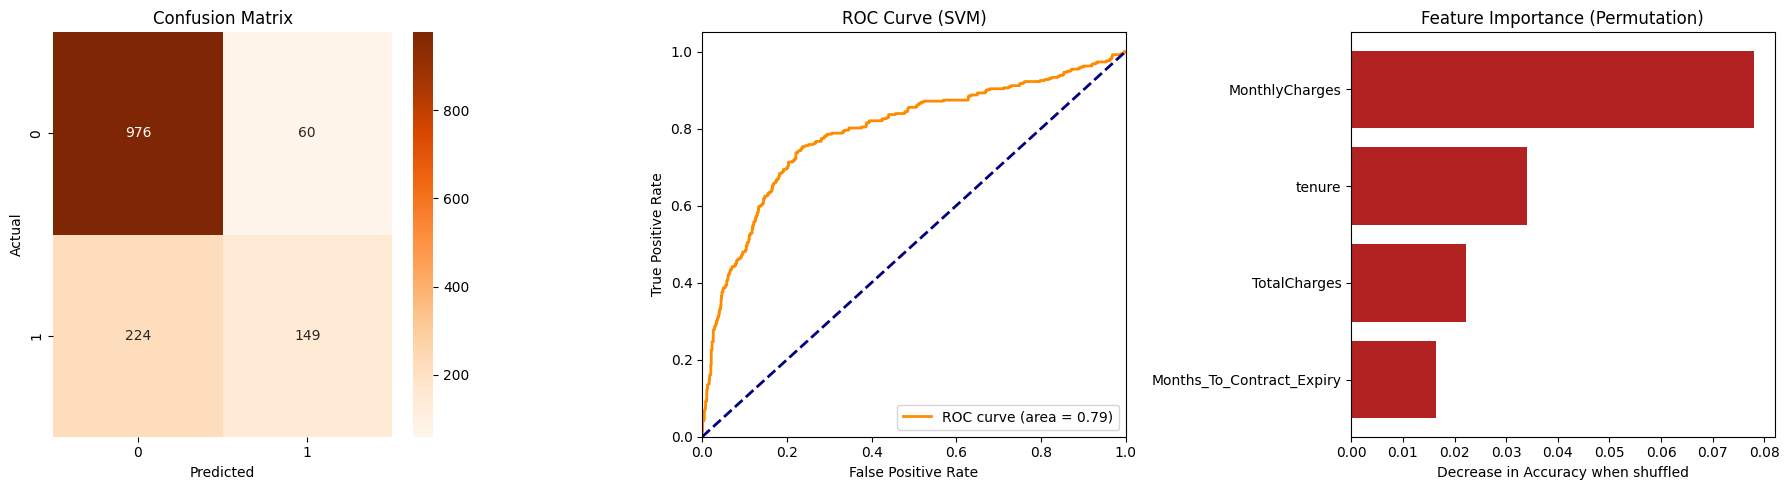


>> [AGENT] SCANNING FOR HIGH RISK CUSTOMERS...
   -> TARGET ACQUIRED: 9237-HQITU
   -> RISK SCORE: 0.68
   -> DETERMINED STRATEGY: Urgent Renewal Offer
--------------------------------------------------

        Subject: Exclusive Offer for our Power User account holder!

        Hi 9237-HQITU,

        We have unlocked a special: >> Urgent Renewal Offer <<

        Best,
        Autonomous Success Agent
        
--------------------------------------------------


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import NelsonAalenFitter
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
import warnings

warnings.filterwarnings('ignore')

class AutonomousRetentionAgent:

    def __init__(self, file_path=None):
        self.file_path = file_path
        self.df = None
        self.model = None
        self.scaler = StandardScaler()
        self.naf = NelsonAalenFitter()
    def load_data(self):
        try:
            print(f">> [System] Attempting to load data from: {self.file_path}")
            self.df = pd.read_csv(self.file_path)
            self.df.columns = self.df.columns.str.strip()

            if 'customerID' not in self.df.columns:
                found = False
                for alt in ['Customer ID', 'id', 'ID']:
                    if alt in self.df.columns:
                        self.df.rename(columns={alt: 'customerID'}, inplace=True)
                        found = True
                        break
                if not found:
                    self.df['customerID'] = [f"Cust-{i}" for i in range(len(self.df))]

            print("   -> Success! Real data loaded.")

            self.df['TotalCharges'] = pd.to_numeric(self.df['TotalCharges'], errors='coerce').fillna(0)

            if 'Churn' in self.df.columns:
                 self.df['Churn_Numeric'] = self.df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)
            else:
                 self.df['Churn_Numeric'] = 0

        except (FileNotFoundError, ValueError, TypeError):
            print("\n   -> WARNING: File not found. Generating Synthetic Data...")
            self.df = self._generate_dummy_data()

        print(">> [System] Engineering Agent Features...")
        self.df['Months_To_Contract_Expiry'] = self.df.apply(self._calculate_cliff, axis=1)

        self.df['Persona'] = np.where(
            self.df['InternetService'] == 'Fiber optic', 'Power User',
            np.where(self.df['MonthlyCharges'] < 50, 'Budget Saver', 'Standard User')
        )
        return self.df

    def _generate_dummy_data(self):
        n = 1000
        data = {
            'customerID': [f'{i:04d}-ID' for i in range(n)],
            'tenure': np.random.randint(1, 72, n),
            'MonthlyCharges': np.random.uniform(30, 120, n),
            'TotalCharges': np.random.uniform(100, 8000, n),
            'Contract': np.random.choice(['Month-to-month', 'One year', 'Two year'], n),
            'InternetService': np.random.choice(['DSL', 'Fiber optic', 'No'], n),
            'Churn_Numeric': np.random.choice([0, 1], n, p=[0.74, 0.26])
        }
        return pd.DataFrame(data)

    def _calculate_cliff(self, row):
        if row['Contract'] == 'Month-to-month': return 1
        elif row['Contract'] == 'One year': return 12 - (row['tenure'] % 12)
        else: return 24 - (row['tenure'] % 24)
    def analyze_survival(self):
        print("\n>> [System] Running Survival Analysis (Nelson-Aalen Hazard)...")
        print("   -> Note: This analyzes cumulative 'Danger' (Hazard) over time.")

        T = self.df['tenure']
        E = self.df['Churn_Numeric']

        self.naf.fit(T, event_observed=E)

        hazard_24_mo = self.naf.predict(24)
        if isinstance(hazard_24_mo, pd.Series):
             hazard_24_mo = hazard_24_mo.iloc[0] if not hazard_24_mo.empty else 0

        print(f"   -> Cumulative Hazard at 24 Months: {hazard_24_mo:.4f}")
        print("      (Higher value = Higher accumulated risk of leaving)")

        plt.figure(figsize=(10, 5))
        self.naf.plot_cumulative_hazard()
        plt.title('Cumulative Hazard Curve (Nelson-Aalen)')
        plt.xlabel('Tenure (Months)')
        plt.ylabel('Cumulative Hazard')
        plt.grid(True, alpha=0.3)
        plt.show()
    def train_model(self):
        print("\n>> [System] Training Support Vector Machine (SVM)...")

        features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Months_To_Contract_Expiry']
        X = self.df[features]
        y = self.df['Churn_Numeric']

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)
        self.model = SVC(kernel='rbf', probability=True, random_state=42)
        self.model.fit(X_train_scaled, y_train)

        y_pred = self.model.predict(X_test_scaled)
        y_prob = self.model.predict_proba(X_test_scaled)[:, 1]

        print("\n" + "="*40)
        print("MODEL PERFORMANCE REPORT (SVM)")
        print("="*40)
        acc = accuracy_score(y_test, y_pred)
        print(f"Accuracy: {acc:.2%}")
        roc_score = roc_auc_score(y_test, y_prob)
        print(f"ROC-AUC Score: {roc_score:.4f}")
        print("-" * 40)
        print("\nClassification Report:\n")
        print(classification_report(y_test, y_pred))
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[0])
        axes[0].set_title('Confusion Matrix')
        axes[0].set_xlabel('Predicted')
        axes[0].set_ylabel('Actual')
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_score:.2f})')
        axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        axes[1].set_xlim([0.0, 1.0])
        axes[1].set_ylim([0.0, 1.05])
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].set_title('ROC Curve (SVM)')
        axes[1].legend(loc="lower right")
        print(">> [System] Calculating Permutation Importance (may take a moment)...")
        perm_importance = permutation_importance(self.model, X_test_scaled, y_test)
        importances = perm_importance.importances_mean
        indices = np.argsort(importances)

        axes[2].set_title('Feature Importance (Permutation)')
        axes[2].barh(range(len(indices)), importances[indices], color='firebrick', align='center')
        axes[2].set_yticks(range(len(indices)))
        axes[2].set_yticklabels([features[i] for i in indices])
        axes[2].set_xlabel('Decrease in Accuracy when shuffled')

        plt.tight_layout()
        plt.show()
        X_scaled = self.scaler.transform(X)
        self.df['Churn_Prob'] = self.model.predict_proba(X_scaled)[:, 1]
    def run_agent_intervention(self):
        print("\n>> [AGENT] SCANNING FOR HIGH RISK CUSTOMERS...")

        if 'Churn_Prob' not in self.df.columns: return

        high_risk_pool = self.df[self.df['Churn_Prob'] > 0.65]

        if high_risk_pool.empty:
            print("   -> No high risk customers found.")
            return

        target = high_risk_pool.iloc[0]
        cust_id = target['customerID']
        risk_score = target['Churn_Prob']
        cliff = target['Months_To_Contract_Expiry']
        persona = target['Persona']

        print(f"   -> TARGET ACQUIRED: {cust_id}")
        print(f"   -> RISK SCORE: {risk_score:.2f}")

        if cliff <= 1:
            strategy = "Urgent Renewal Offer"
        elif target['MonthlyCharges'] > 90:
            strategy = "Discount Bundle"
        else:
            strategy = "Loyalty Perk"

        print(f"   -> DETERMINED STRATEGY: {strategy}")
        print("-" * 50)
        print(self._generate_email(cust_id, persona, strategy))
        print("-" * 50)

    def _generate_email(self, name, persona, strategy):
        return f"""
        Subject: Exclusive Offer for our {persona} account holder!

        Hi {name},

        We have unlocked a special: >> {strategy} <<

        Best,
        Autonomous Success Agent
        """

if __name__ == "__main__":
    dataset_path = '/content/WA_Fn-UseC_-Telco-Customer-Churn.csv'
    agent = AutonomousRetentionAgent(file_path=dataset_path)
    agent.load_data()
    agent.analyze_survival()
    agent.train_model()
    agent.run_agent_intervention()

>> Data loaded successfully.

--- 9.2.2 STATISTICAL & VISUAL VALIDATION OF SURVIVAL MODELS ---

>> AIC SCORES (Lower indicates better parametric fit):
   Weibull AIC:    21156.58
   Log-Normal AIC: 21041.13
   -> RESULT: Log-Normal provides a better statistical fit.


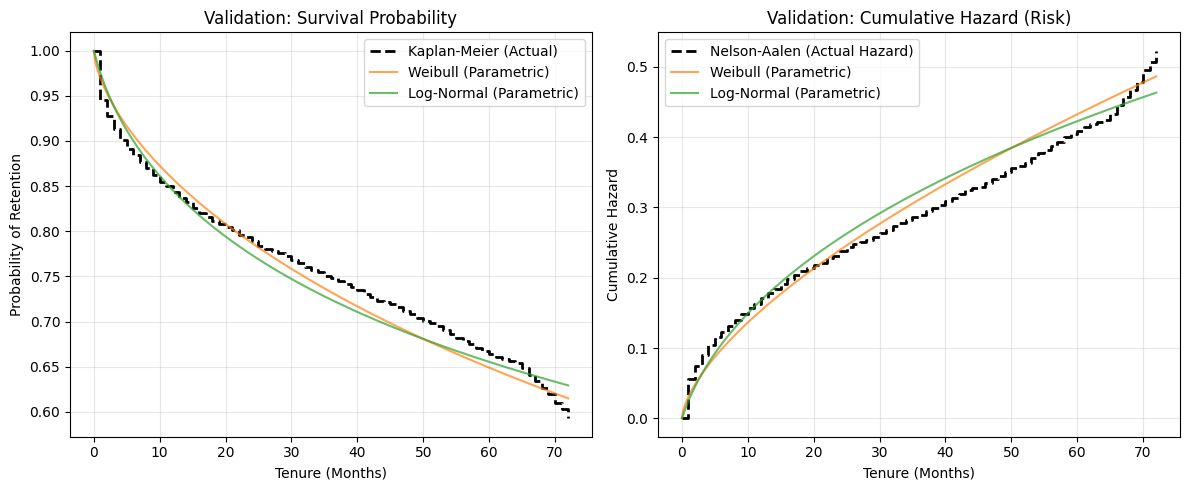

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import WeibullFitter, LogNormalFitter, KaplanMeierFitter, NelsonAalenFitter

# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================
file_path = '/content/WA_Fn-UseC_-Telco-Customer-Churn.csv'

try:
    df = pd.read_csv(file_path)
    print(">> Data loaded successfully.")
except FileNotFoundError:
    print(f"Error: File not found at {file_path}")
    # Create dummy data for testing
    df = pd.DataFrame({
        'tenure': np.random.randint(1, 72, 100),
        'Churn': np.random.choice(['Yes', 'No'], 100),
        'TotalCharges': np.random.uniform(100, 5000, 100)
    })

# --- Preprocessing ---
# 1. Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

# 2. Encode Target
df['Churn_Numeric'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# 3. Handle Zero Tenure (Add epsilon for parametric models)
df['tenure_adj'] = df['tenure'].replace(0, 0.001)

# ==========================================
# 2. DEFINE VALIDATION FUNCTION
# ==========================================
def validate_survival_analysis(data):
    print("\n" + "="*60)
    print("--- 9.2.2 STATISTICAL & VISUAL VALIDATION OF SURVIVAL MODELS ---")
    print("="*60)

    T = data['tenure_adj']
    E = data['Churn_Numeric']

    # --- FIT MODELS ---
    wf = WeibullFitter()
    wf.fit(T, event_observed=E, label='Weibull (Parametric)')

    lnf = LogNormalFitter()
    lnf.fit(T, event_observed=E, label='Log-Normal (Parametric)')

    kmf = KaplanMeierFitter()
    kmf.fit(T, event_observed=E, label='Kaplan-Meier (Actual)')

    naf = NelsonAalenFitter()
    naf.fit(T, event_observed=E, label='Nelson-Aalen (Actual Hazard)')

    # ==========================================
    # METRIC 1: AIC SCORE (Goodness of Fit)
    # ==========================================
    print(f"\n>> AIC SCORES (Lower indicates better parametric fit):")
    print(f"   Weibull AIC:    {wf.AIC_:.2f}")
    print(f"   Log-Normal AIC: {lnf.AIC_:.2f}")

    if lnf.AIC_ < wf.AIC_:
        print("   -> RESULT: Log-Normal provides a better statistical fit.")
    else:
        print("   -> RESULT: Weibull provides a better statistical fit.")

    # Note: C-Index is skipped here because univariate models (without features)
    # cannot rank customers individually. C-Index applies to regression models
    # like CoxPH or WeibullAFT which use features to predict risk.

    # ==========================================
    # VISUAL CONFIRMATION 1: SURVIVAL CURVE
    # ==========================================
    plt.figure(figsize=(12, 5))

    # Subplot 1: Survival Probability
    plt.subplot(1, 2, 1)
    kmf.plot_survival_function(ci_show=False, color='black', linewidth=2, linestyle='--', ax=plt.gca())
    wf.plot_survival_function(ci_show=False, alpha=0.7, ax=plt.gca())
    lnf.plot_survival_function(ci_show=False, alpha=0.7, ax=plt.gca())

    plt.title('Validation: Survival Probability')
    plt.ylabel('Probability of Retention')
    plt.xlabel('Tenure (Months)')
    plt.grid(True, alpha=0.3)

    # ==========================================
    # VISUAL CONFIRMATION 2: CUMULATIVE HAZARD
    # ==========================================
    # Subplot 2: Cumulative Hazard
    plt.subplot(1, 2, 2)
    naf.plot_cumulative_hazard(ci_show=False, color='black', linewidth=2, linestyle='--', ax=plt.gca())
    wf.plot_cumulative_hazard(ci_show=False, alpha=0.7, ax=plt.gca())
    lnf.plot_cumulative_hazard(ci_show=False, alpha=0.7, ax=plt.gca())

    plt.title('Validation: Cumulative Hazard (Risk)')
    plt.ylabel('Cumulative Hazard')
    plt.xlabel('Tenure (Months)')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ==========================================
# 3. RUN VALIDATION
# ==========================================
if __name__ == "__main__":
    validate_survival_analysis(df)